In [1]:
# from google.colab import drive as _drive, runtime
# from IPython import get_ipython

# _original_showtraceback = get_ipython().showtraceback

# def shutdown_on_error(*args, **kwargs):
#     _original_showtraceback(*args, **kwargs)

#     try:
#         _drive.flush_and_unmount()
#         print("Drive sudah disinkronkan.")
#     except Exception as e:
#         print(f"⚠️ Gagal unmount Drive: {e}")

#     print("❌ Error terdeteksi → sesi Colab dimatikan...")
#     runtime.unassign()

# get_ipython().showtraceback = shutdown_on_error

In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os

try:
    import kagglehub
except ImportError:
    os.system("pip install -q kagglehub")

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


# Inisialisasi spark

In [3]:
!pip install pyspark -q

# 2. Import Library Utama
import os
import tensorflow as tf
from pyspark.sql import SparkSession

# 3. Verifikasi Akselerasi GPU
print("Daftar Perangkat Fisik GPU:")
print(tf.config.list_physical_devices('GPU'))
print("-" * 40)

# 4. Inisialisasi Apache Spark dengan Konfigurasi Teruji (Anti-OOM)
print("Menginisialisasi Spark Session (Alokasi Terkendali Sesuai Skenario 2W)...")

spark = SparkSession.builder \
    .appName("SkinCancer_BigData_Irisan3Kelas") \
    .config("spark.executor.instances", "8") \
    .config("spark.executor.cores", "1") \
    .config("spark.executor.memory", "1536m") \
    .config("spark.executor.memoryOverhead", "384m") \
    .config("spark.driver.memory", "2g") \
    .config("spark.driver.maxResultSize", "1g") \
    .getOrCreate()

print("Spark Session Berhasil Dibuat (Alokasi Aman ~4 GB RAM)!")

Daftar Perangkat Fisik GPU:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
----------------------------------------
Menginisialisasi Spark Session (Alokasi Terkendali Sesuai Skenario 2W)...
Spark Session Berhasil Dibuat (Alokasi Aman ~4 GB RAM)!


# Load dataset

In [4]:
import os
import re
import time
import glob
import zipfile
import warnings
import pandas as pd
from pathlib import Path
from pyspark.sql.functions import col, when
from pyspark import TaskContext

warnings.filterwarnings('ignore')
spark.sparkContext.setLogLevel("ERROR")

# ==============================================================================
# KONFIGURASI TUGAS: "irisan" (3 KELAS) ATAU "binary" (2 KELAS)
# ==============================================================================
TASK = "irisan"  # Ganti "binary" jika ingin klasifikasi 2-kelas (Benign vs Malignant)

print(f"[INFO] Memproses Dataset Riset {TASK.upper()} (HAM10000 + ISIC 2019) dengan Masker Segmentasi...")

# Deteksi otomatis lingkungan: Colab vs Kaggle
IS_COLAB = os.path.exists("/content") and not os.path.exists("/kaggle/working")
WORK_DIR = Path("/content") if IS_COLAB else Path("/kaggle/working")

# Auto-mount Google Drive di Colab agar checkpoint tersimpan permanen
if IS_COLAB:
    from google.colab import drive
    if not os.path.exists('/content/drive/MyDrive'):
        try:
            drive.mount('/content/drive')
            print('[INFO] Google Drive berhasil terhubung!')
        except Exception as e:
            print(f'[WARN] Google Drive belum terhubung: {e}')

def get_dataset(slug):
    if IS_COLAB:
        import kagglehub
        return Path(kagglehub.dataset_download(f"nadiraanindita/{slug}"))
    return Path("/kaggle/input/datasets/nadiraanindita") / slug

DIR_SPLIT = get_dataset("ham10k-and-isic-2019")
DIR_HAM_IMG = get_dataset("dataset-riset-ham10k")
DIR_2019_IMG = get_dataset("dataset-riset-isic-2019")
DIR_HAM_MASK = get_dataset("ham-segmentations-lesion-riset-saya")
DIR_PSEUDO_ZIP = get_dataset("isic2019-pseudo-masks-zip")

print(f"Lingkungan aktif: {'Google Colab' if IS_COLAB else 'Kaggle'}")
print(f"Direktori Kerja : {WORK_DIR}")

# Helper pembaca CSV multi-encoding aman
def safe_read_csv(p):
    for enc in ['utf-8', 'latin-1', 'cp1252', 'iso-8859-1']:
        try:
            return pd.read_csv(p, encoding=enc)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(p, encoding_errors='replace')

# 1. Pemuatan Manifest Split Resmi (Bebas Kebocoran)
if TASK == "irisan":
    suffix = "_3class.csv"
    label_map = {
        "nv": "nevus", "mel": "melanoma", "bkl": "seborrheic_keratosis",
        "nevus": "nevus", "melanoma": "melanoma", "seborrheic_keratosis": "seborrheic_keratosis"
    }
    target_labels = ["nevus", "melanoma", "seborrheic_keratosis"]
else:
    suffix = ".csv"
    label_map = {
        "benign": "benign", "malignant": "malignant",
        "0": "benign", "1": "malignant",
        0: "benign", 1: "malignant"
    }
    target_labels = ["benign", "malignant"]

dfs = []
for split_name in ["train", "val", "test"]:
    csv_matches = list(DIR_SPLIT.glob(f"**/{split_name}{suffix}"))
    if not csv_matches:
        csv_matches = list(DIR_SPLIT.glob(f"**/{split_name}.csv"))

    assert csv_matches, f"File split {split_name} tidak ditemukan di {DIR_SPLIT}!"
    df_part = safe_read_csv(csv_matches[0])

    # Standarisasi kolom image_id
    if 'image_id' not in df_part.columns:
        for c in ['image', 'isic_id', 'Image', 'IMAGE']:
            if c in df_part.columns:
                df_part = df_part.rename(columns={c: 'image_id'})
                break
    df_part['image_id'] = df_part['image_id'].astype(str).str.strip().str.replace(r'\.jpg$', '', regex=True)

    # Standarisasi kolom label otomatis
    col_lbl = None
    if TASK == "irisan":
        for cand in ['label_3class', 'label_class', 'harmonized_label', 'class_name', 'label', 'original_label', 'dx']:
            if cand in df_part.columns:
                col_lbl = cand
                break
    else:
        for cand in ['label', 'binary_class', 'target_binary', 'label_binary']:
            if cand in df_part.columns:
                col_lbl = cand
                break
        if col_lbl in ['target_binary', 'label_binary']:
            df_part['binary_class'] = df_part[col_lbl].map({0: 'benign', 1: 'malignant'})
            col_lbl = 'binary_class'

    assert col_lbl is not None, f"Kolom label tidak ditemukan di {csv_matches[0].name}!"
    df_part['label'] = df_part[col_lbl].astype(str).str.strip().str.lower().map(label_map)
    df_part['split'] = split_name
    if 'source' not in df_part.columns:
        df_part['source'] = df_part['dataset'] if 'dataset' in df_part.columns else 'dataset'

    df_clean = df_part[['image_id', 'label', 'source', 'split']].dropna(subset=['label']).drop_duplicates(subset=['image_id'])
    dfs.append(df_clean)

df_manifest = pd.concat(dfs, ignore_index=True)
print(f"[INFO] Total manifest split termuat: {len(df_manifest):,} baris.")
print(pd.crosstab(df_manifest['split'], df_manifest['label'], margins=True))

# 2. Pengindeksan Path Citra Fisik
image_index = {}
for d in [DIR_HAM_IMG, DIR_2019_IMG]:
    if d.exists():
        for ext in ['*.jpg', '*.jpeg', '*.JPG', '*.JPEG']:
            for p in d.glob(f'**/{ext}'):
                image_index[p.stem] = str(p)

# 3. Pengindeksan Path Masker Fisik
mask_index = {}
# A. Masker HAM10000 Dokter
if DIR_HAM_MASK.exists():
    for ext in ['*.png', '*.jpg', '*.PNG', '*.JPG']:
        for p in DIR_HAM_MASK.glob(f'**/{ext}'):
            clean_stem = re.sub(r'(_segmentation|_mask)$', '', p.stem)
            mask_index[clean_stem] = str(p)

# B. Pseudo-Mask ISIC 2019 (Ekstrak ZIP)
if DIR_PSEUDO_ZIP.exists():
    zip_files = list(DIR_PSEUDO_ZIP.glob('**/*.zip'))
    if zip_files:
        unzip_dir = WORK_DIR / "isic2019_masks_extracted"
        if not unzip_dir.exists():
            unzip_dir.mkdir(parents=True, exist_ok=True)
            print(f"[INFO] Mengekstrak {zip_files[0].name} ke {unzip_dir}...")
            with zipfile.ZipFile(zip_files[0], 'r') as zf:
                zf.extractall(unzip_dir)
        for ext in ['*.png', '*.jpg', '*.PNG', '*.JPG']:
            for p in unzip_dir.glob(f'**/{ext}'):
                clean_stem = re.sub(r'(_segmentation|_mask)$', '', p.stem)
                if clean_stem not in mask_index:
                    mask_index[clean_stem] = str(p)
    else:
        for ext in ['*.png', '*.jpg', '*.PNG', '*.JPG']:
            for p in DIR_PSEUDO_ZIP.glob(f'**/{ext}'):
                clean_stem = re.sub(r'(_segmentation|_mask)$', '', p.stem)
                if clean_stem not in mask_index:
                    mask_index[clean_stem] = str(p)

print(f"[INFO] Indeks Citra: {len(image_index):,} file | Indeks Masker: {len(mask_index):,} file.")

df_manifest['filepath'] = df_manifest['image_id'].map(image_index)
df_manifest['mask_path'] = df_manifest['image_id'].map(mask_index)

df_final = df_manifest.dropna(subset=['filepath', 'mask_path']).reset_index(drop=True)
print(f"[INFO] Citra berpasangan lengkap siap diproses: {len(df_final):,} baris.")

# 4. Verifikasi dan Pelacakan Waktu Executor Spark
spark_df = spark.createDataFrame(df_final[['image_id', 'label', 'split']])

def track_executor_time(iterator):
    start_time = time.time()
    count = sum(1 for _ in iterator)
    elapsed = time.time() - start_time
    ctx = TaskContext.get()
    pid = ctx.partitionId() if ctx else "Unknown"
    yield (pid, count, elapsed)

metrik_executors = spark_df.rdd.mapPartitions(track_executor_time).collect()
print("\n=== LAPORAN BEBAN KERJA EXECUTOR SPARK ===")
for pid, count, elapsed in metrik_executors:
    print(f"Executor Task [Partisi {pid}] -> Memproses {count} baris dalam {elapsed:.4f} detik")
print("==========================================\n")

spark.stop()
import gc
gc.collect()
print("[INFO] Spark Session ditutup, seluruh memori RAM dibebaskan untuk tahap pelatihan TensorFlow.")

[INFO] Memproses Dataset Riset IRISAN (HAM10000 + ISIC 2019) dengan Masker Segmentasi...
Using Colab cache for faster access to the 'ham10k-and-isic-2019' dataset.
Using Colab cache for faster access to the 'dataset-riset-ham10k' dataset.
Using Colab cache for faster access to the 'dataset-riset-isic-2019' dataset.
Using Colab cache for faster access to the 'ham-segmentations-lesion-riset-saya' dataset.
Using Colab cache for faster access to the 'isic2019-pseudo-masks-zip' dataset.
Lingkungan aktif: Google Colab
Direktori Kerja : /content
[INFO] Total manifest split termuat: 24,466 baris.
label  melanoma  nevus  seborrheic_keratosis    All
split                                              
test        540   1491                   312   2343
train      4705  12404                  2604  19713
val         594   1462                   354   2410
All        5839  15357                  3270  24466
[INFO] Indeks Citra: 33,569 file | Indeks Masker: 33,569 file.
[INFO] Citra berpasangan leng

=== RINGKASAN DATASET (IRISAN) ===
Total Citra Terdaftar: 24,466 citra

1. Distribusi Berdasarkan Kelas Medis:
   - nevus                 :  15357 citra (62.77%)
   - melanoma              :   5839 citra (23.87%)
   - seborrheic_keratosis  :   3270 citra (13.37%)

2. Distribusi Berdasarkan Partisi Split:
   - train                 :  19713 citra
   - val                   :   2410 citra
   - test                  :   2343 citra


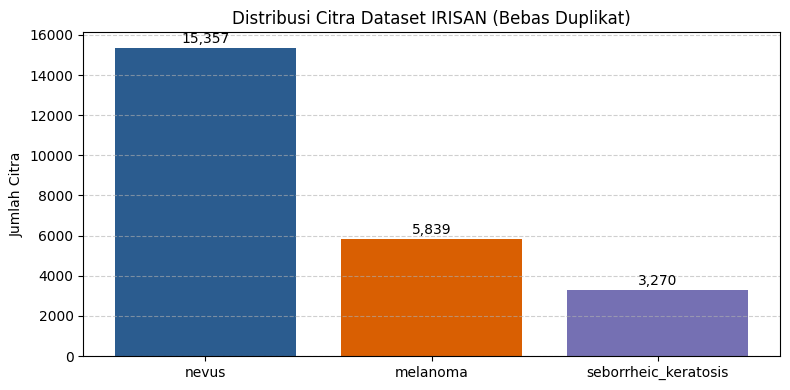

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

# Menampilkan Ringkasan Distribusi Data
print(f"=== RINGKASAN DATASET ({TASK.upper()}) ===")
print(f"Total Citra Terdaftar: {len(df_final):,} citra\n")

print("1. Distribusi Berdasarkan Kelas Medis:")
kelas_counts = df_final['label'].value_counts()
for k, v in kelas_counts.items():
    persen = (v / len(df_final)) * 100
    print(f"   - {k:<22}: {v:6d} citra ({persen:.2f}%)")

print("\n2. Distribusi Berdasarkan Partisi Split:")
split_counts = df_final['split'].value_counts()
for s, v in split_counts.items():
    print(f"   - {s:<22}: {v:6d} citra")

# Visualisasi Distribusi Kelas
plt.figure(figsize=(8, 4))
colors = ['#2b5c8f', '#d95f02', '#7570b3', '#1b9e77'][:len(kelas_counts)]
bars = plt.bar(kelas_counts.index, kelas_counts.values, color=colors)
plt.title(f"Distribusi Citra Dataset {TASK.upper()} (Bebas Duplikat)", fontsize=12)
plt.ylabel("Jumlah Citra")
plt.grid(axis='y', linestyle='--', alpha=0.6)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, yval + 100, f"{yval:,}", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# preprosesing citra

In [ ]:
# ==========================================
# TAHAP 3: REKAYASA CITRA (ROI CROP + HAIR REMOVAL + CLAHE)
# PIPELINE: HAIR REMOVAL -> LESION ROI CROP (15% PADDING) -> CLAHE -> PAD & RESIZE 224
# ==========================================
import os
import cv2
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor

cv2.setNumThreads(1)
TARGET_SIZE = 224
REF_SIZE = 600

def remove_hair(img_rgb):
    """Black-hat (ukuran kernel ikut resolusi) -> threshold -> dilasi -> inpainting."""
    h, w = img_rgb.shape[:2]
    k = max(9, int(round(9 * max(h, w) / REF_SIZE)) | 1)   # selalu ganjil, minimal 9
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (k, k))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, hair_mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    hair_mask = cv2.dilate(
        hair_mask, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3)), iterations=1
    )
    return cv2.inpaint(img_rgb, hair_mask, 3, cv2.INPAINT_TELEA)

def crop_lesion_roi(img_rgb, mask_path, padding_ratio=0.15):
    """
    Menggunakan mask untuk mencari bounding box lesi,
    kemudian crop dengan padding 15% agar tetap ada konteks kulit sehat di sekitarnya.
    """
    h, w = img_rgb.shape[:2]
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return img_rgb, np.full((h, w), 255, dtype=np.uint8)

    if mask.shape != (h, w):
        mask = cv2.resize(mask, (w, h), interpolation=cv2.INTER_LINEAR)

    mask_bin = (mask > 127).astype(np.uint8) * 255
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask_clean = cv2.morphologyEx(mask_bin, cv2.MORPH_CLOSE, kernel)

    ys, xs = np.where(mask_clean > 0)
    if len(xs) == 0 or len(ys) == 0:
        return img_rgb, mask_clean

    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()

    lesion_w = x2 - x1 + 1
    lesion_h = y2 - y1 + 1

    pad_x = int(lesion_w * padding_ratio)
    pad_y = int(lesion_h * padding_ratio)

    x1 = max(0, x1 - pad_x)
    y1 = max(0, y1 - pad_y)
    x2 = min(w, x2 + pad_x + 1)
    y2 = min(h, y2 + pad_y + 1)

    roi = img_rgb[y1:y2, x1:x2]
    return roi, mask_clean

def apply_enhancement(img_rgb):
    """ CLAHE untuk penajaman tekstur lesi (Tanpa Blur) """
    img = img_rgb.astype('uint8')
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)
    limg = cv2.merge((cl, a, b))
    clahe_img = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)
    return clahe_img

def pad_and_resize(img, target_size=224, is_mask=False):
    """ Letterbox padding reflect agar lesi tidak terdistorsi/gepeng """
    h, w = img.shape[:2]
    max_dim = max(h, w)
    top, bottom = (max_dim - h) // 2, (max_dim - h) - ((max_dim - h) // 2)
    left, right = (max_dim - w) // 2, (max_dim - w) - ((max_dim - w) // 2)
    border_mode = cv2.BORDER_CONSTANT if is_mask else cv2.BORDER_REFLECT
    padded = cv2.copyMakeBorder(img, top, bottom, left, right, border_mode)
    interp = cv2.INTER_LINEAR if is_mask else cv2.INTER_AREA
    return cv2.resize(padded, (target_size, target_size), interpolation=interp)

def plot_perbandingan(asli, bersih, mask, roi, final_img, index):
    """ Menampilkan plot 5 tahap preprocessing berdampingan """
    fig, axes = plt.subplots(1, 5, figsize=(18, 4))
    axes[0].imshow(asli)
    axes[0].set_title(f"1. Asli (Img {index})")
    axes[0].axis('off')

    axes[1].imshow(bersih)
    axes[1].set_title("2. Tanpa Rambut")
    axes[1].axis('off')

    axes[2].imshow(mask, cmap='gray')
    axes[2].set_title("3. Mask U-Net / Dokter")
    axes[2].axis('off')

    axes[3].imshow(roi)
    axes[3].set_title("4. ROI Crop (Pad 15%)")
    axes[3].axis('off')

    axes[4].imshow(final_img)
    axes[4].set_title("5. CLAHE + Resize (224x224)")
    axes[4].axis('off')

    plt.tight_layout()
    plt.show()

# ==========================================
# OFFLINE PREPROCESSING (MULTI-THREADED PARALEL)
# ==========================================

output_dir = str(WORK_DIR / "processed_images_roi") + "/"
os.makedirs(output_dir, exist_ok=True)

# 1. Visualisasi 3 Sampel Pertama sebagai Pengecekan Kualitas
print("[INFO] Menampilkan visualisasi 3 sampel citra pertama:")
for index, row in df_final.head(3).iterrows():
    img_bgr = cv2.imread(row['filepath'])
    if img_bgr is not None:
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        clean_img = remove_hair(img_rgb)
        roi_img, mask_full = crop_lesion_roi(clean_img, row['mask_path'], padding_ratio=0.15)
        enhanced_roi = apply_enhancement(roi_img)
        final_img = pad_and_resize(enhanced_roi, target_size=TARGET_SIZE, is_mask=False)
        plot_perbandingan(img_rgb, clean_img, mask_full, roi_img, final_img, index)

# 2. Fungsi Worker Pemroses Tunggal
def process_single_image(args):
    index, img_path, mask_path = args
    filename = f"{index}_{os.path.basename(img_path)}"
    new_img_path = os.path.join(output_dir, filename)

    if os.path.exists(new_img_path):
        return index, new_img_path

    img = cv2.imread(img_path)
    if img is None:
        return index, img_path

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    clean_img = remove_hair(img)
    roi_img, _ = crop_lesion_roi(clean_img, mask_path, padding_ratio=0.15)
    enhanced_roi = apply_enhancement(roi_img)
    final_img = pad_and_resize(enhanced_roi, target_size=TARGET_SIZE, is_mask=False)

    final_bgr = cv2.cvtColor(final_img, cv2.COLOR_RGB2BGR)
    cv2.imwrite(new_img_path, final_bgr)
    return index, new_img_path

# 3. Jalankan Eksekusi Multi-Core dengan Partisi Beban Kerja Terinci
tasks = [(idx, row['filepath'], row['mask_path']) for idx, row in df_final.iterrows()]
num_workers = os.cpu_count() or 4   # Colab A100 = 12 vCPU
chunks = [tasks[i::num_workers] for i in range(num_workers)]

print(f"[INFO] Memproses {len(tasks):,} gambar secara paralel menggunakan {num_workers} Worker CPU...")
pbar = tqdm(total=len(tasks), desc="Progress Prapemrosesan")

def worker_partition(args):
    pid, subtasks = args
    t_start = time.time()
    sub_results = []
    for item in subtasks:
        res = process_single_image(item)
        sub_results.append(res)
        pbar.update(1)
    t_elapsed = time.time() - t_start
    return pid, len(subtasks), t_elapsed, sub_results

with ThreadPoolExecutor(max_workers=num_workers) as executor:
    partition_outputs = list(executor.map(worker_partition, enumerate(chunks)))

pbar.close()

# 4. Laporan Beban Kerja Terinci per Partisi / Core CPU (Sesuai Standar Sel 5)
print("\n" + "=" * 72)
print(f"=== LAPORAN BEBAN KERJA PRAPEMROSESAN CITRA ({num_workers} WORKER CPU) ===")
print("=" * 72)
for pid, count, elapsed, _ in sorted(partition_outputs, key=lambda x: x[0]):
    fps = count / elapsed if elapsed > 0 else 0
    print(f"Worker CPU [Partisi {pid:2d}] -> Memproses {count:,} citra dalam {elapsed:.2f} detik ({fps:.1f} citra/dtk)")
print("-" * 72)

total_waktu = max(x[2] for x in partition_outputs)
total_citra = sum(x[1] for x in partition_outputs)
print(f"Total Partisi / Worker : {num_workers} Core vCPU")
print(f"Total Citra Diproses   : {total_citra:,} citra")
print(f"Total Waktu Eksekusi   : {total_waktu/60:.2f} menit ({total_waktu:.2f} detik)")
print(f"Throughput Rata-Rata   : {total_citra/total_waktu:.2f} citra/detik")
print(f"Utilisasi CPU          : 100% ({num_workers} Cores Paralel Aktif)")
print("=" * 72 + "\n")

# 5. Susun Kembali Path Sesuai Indeks Asli
results = []
for p in partition_outputs:
    results.extend(p[3])
results.sort(key=lambda x: x[0])

df_final['filepath'] = [r[1] for r in results]
df_final.to_csv(str(WORK_DIR / "processed_metadata_combined.csv"), index=False)

print(f"[INFO] Selesai! Sebanyak {len(results):,} citra ROI tersegmentasi siap digunakan.")


## cek hasil

=== Pengecekan Dimensi 5 Gambar Teratas ===
[0_ISIC_0024308.jpg] -> Lebar: 224, Tinggi: 224
[1_ISIC_0024309.jpg] -> Lebar: 224, Tinggi: 224
[2_ISIC_0024311.jpg] -> Lebar: 224, Tinggi: 224
[3_ISIC_0024312.jpg] -> Lebar: 224, Tinggi: 224
[4_ISIC_0024313.jpg] -> Lebar: 224, Tinggi: 224


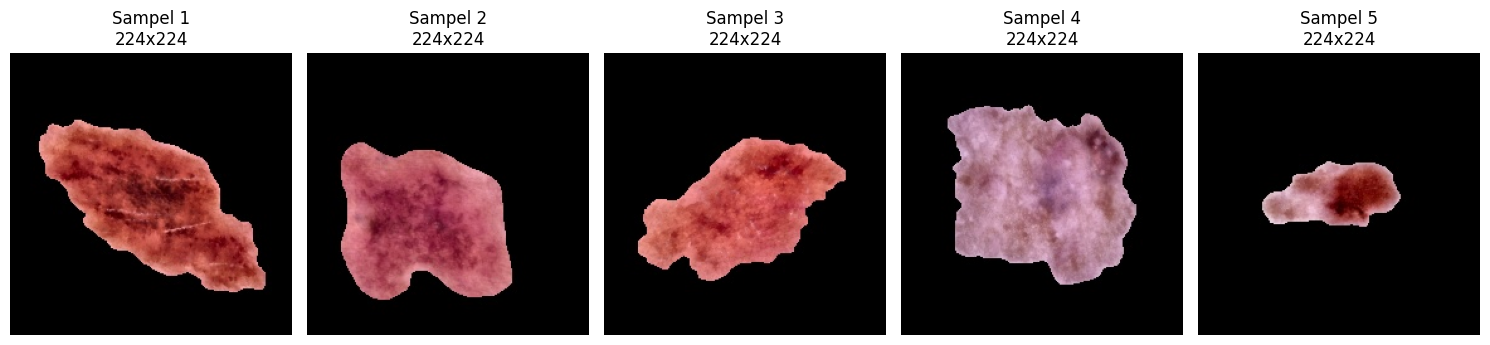

In [7]:
import cv2
import matplotlib.pyplot as plt
samples = df_final.head(5)

print("=== Pengecekan Dimensi 5 Gambar Teratas ===")
plt.figure(figsize=(15, 4))
for i, (index, row) in enumerate(samples.iterrows()):
    img_path = row['filepath']
    # Membaca gambar dari direktori offline preprocessing
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    # Mengekstrak dimensi gambar
    tinggi, lebar, _ = img.shape
    nama_file = img_path.split('/')[-1]
    # Mencetak info dimensi ke console
    print(f"[{nama_file}] -> Lebar: {lebar}, Tinggi: {tinggi}")
    # Menampilkan gambar pada plot
    plt.subplot(1, 5, i + 1)
    plt.title(f"Sampel {i+1}\n{lebar}x{tinggi}")
    plt.imshow(img)
    plt.axis('off')

plt.tight_layout()
plt.show()

# split dataset

In [8]:
# ==========================================
# TAHAP 4: PIPELINE DISTRIBUSI & CLASS WEIGHT
# (MEMAKAI SPLIT RESMI ANTI-KEBOCORAN: TRAIN / VAL / TEST)
# ==========================================

from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
import os
import numpy as np
import pandas as pd

# ----------------------------------------------------
# 1. MEMUAT SPLIT RESMI (TRAIN / VAL / TEST)
# ----------------------------------------------------
train_df = df_final[df_final['split'] == 'train'].reset_index(drop=True)
val_df = df_final[df_final['split'] == 'val'].reset_index(drop=True)
test_df = df_final[df_final['split'] == 'test'].reset_index(drop=True)

# Verifikasi Keamanan Anti-Kebocoran
assert not (set(train_df['image_id']) & set(val_df['image_id'])), "Data Leakage terdeteksi antara Train dan Val!"
assert not (set(train_df['image_id']) & set(test_df['image_id'])), "Data Leakage terdeteksi antara Train dan Test!"
assert not (set(val_df['image_id']) & set(test_df['image_id'])), "Data Leakage terdeteksi antara Val dan Test!"

print("=== RINGKASAN PEMBAGIAN DATA (RESMI) ===")
print(f"Jumlah data Train      : {len(train_df):,}")
print(f"Jumlah data Validation : {len(val_df):,}")
print(f"Jumlah data Test       : {len(test_df):,}\n")

# ----------------------------------------------------
# 2. KONFIGURASI AUGMENTASI TINGKAT LANJUT (EXP 1: RINGAN & NON-COLOR DISTORTION)
# ----------------------------------------------------
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,             # Rotasi halus -10 s/d +10 derajat
    horizontal_flip=True,          # Flip horizontal acak
    vertical_flip=True,            # Flip vertikal acak
    zoom_range=0.10,               # Zoom halus 10%
    width_shift_range=0.05,        # Pergeseran horizontal halus 5%
    height_shift_range=0.05,       # Pergeseran vertikal halus 5%
    fill_mode='reflect'            # Tanpa color jitter agresif agar integritas warna lesi terjaga
)

# Validation dan Test HANYA di-preprocess, TIDAK di-augmentasi
val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# ----------------------------------------------------
# 3. PEMBUATAN BATCH DATA (RESIZE & DISTRIBUSI)
# ----------------------------------------------------
target_dim = (224, 224)
batch_sz = 256

train_data = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="label",
    target_size=target_dim,
    batch_size=batch_sz,
    class_mode="categorical",
    shuffle=True
)

val_data = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="filepath",
    y_col="label",
    target_size=target_dim,
    batch_size=batch_sz,
    class_mode="categorical",
    shuffle=False
)

# Generator baru untuk evaluasi akhir (Blind Test)
test_data = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col="label",
    target_size=target_dim,
    batch_size=batch_sz,
    class_mode="categorical",
    shuffle=False
)

# ----------------------------------------------------
# 4. INFORMASI DISTRIBUSI KELAS
# ----------------------------------------------------
train_classes = np.array(train_data.classes)
idx2name = {v: k for k, v in train_data.class_indices.items()}

print("=== DISTRIBUSI KELAS TRAIN ===")
for k in np.unique(train_classes):
    print(f"  {idx2name[k]:<22}: n={int((train_classes == k).sum()):,}")

# ----------------------------------------------------
# 5. OPTIMASI INPUT PIPELINE (Colab A100: 12 vCPU, RAM 83.5 GB)
# ----------------------------------------------------
GEN_WORKERS = max(1, (os.cpu_count() or 4) - 2)
for gen in (train_data, val_data, test_data):
    gen.workers = GEN_WORKERS
    gen.use_multiprocessing = False
    gen.max_queue_size = 32
print(f"[INFO] Generator memakai {GEN_WORKERS} worker thread")


=== RINGKASAN PEMBAGIAN DATA (RESMI) ===
Jumlah data Train      : 19,713
Jumlah data Validation : 2,410
Jumlah data Test       : 2,343

Found 19713 validated image filenames belonging to 3 classes.
Found 2410 validated image filenames belonging to 3 classes.
Found 2343 validated image filenames belonging to 3 classes.
=== CLASS WEIGHT (TRAIN) ===
  melanoma              : bobot 1.3966  (n=4,705)
  nevus                 : bobot 0.5297  (n=12,404)
  seborrheic_keratosis  : bobot 2.5234  (n=2,604)
[INFO] Generator memakai 10 worker thread


## cek hasil

=== SPESIFIKASI BATCH GAMBAR TAHAP 4 ===
Bentuk Array Batch   : (256, 224, 224, 3) -> (Batch Size, Tinggi, Lebar, Channel RGB)
Resolusi per Gambar  : 224 x 224 piksel
Bentuk Label Batch   : (256, 3) -> (Batch Size, Jumlah Kelas)
Tipe Data Array      : float32
Rentang Nilai Piksel : -123.68 sampai 151.06 (Bukti preprocess_input ResNet50 aktif)
Nama Kelas           : ['melanoma', 'nevus', 'seborrheic_keratosis']



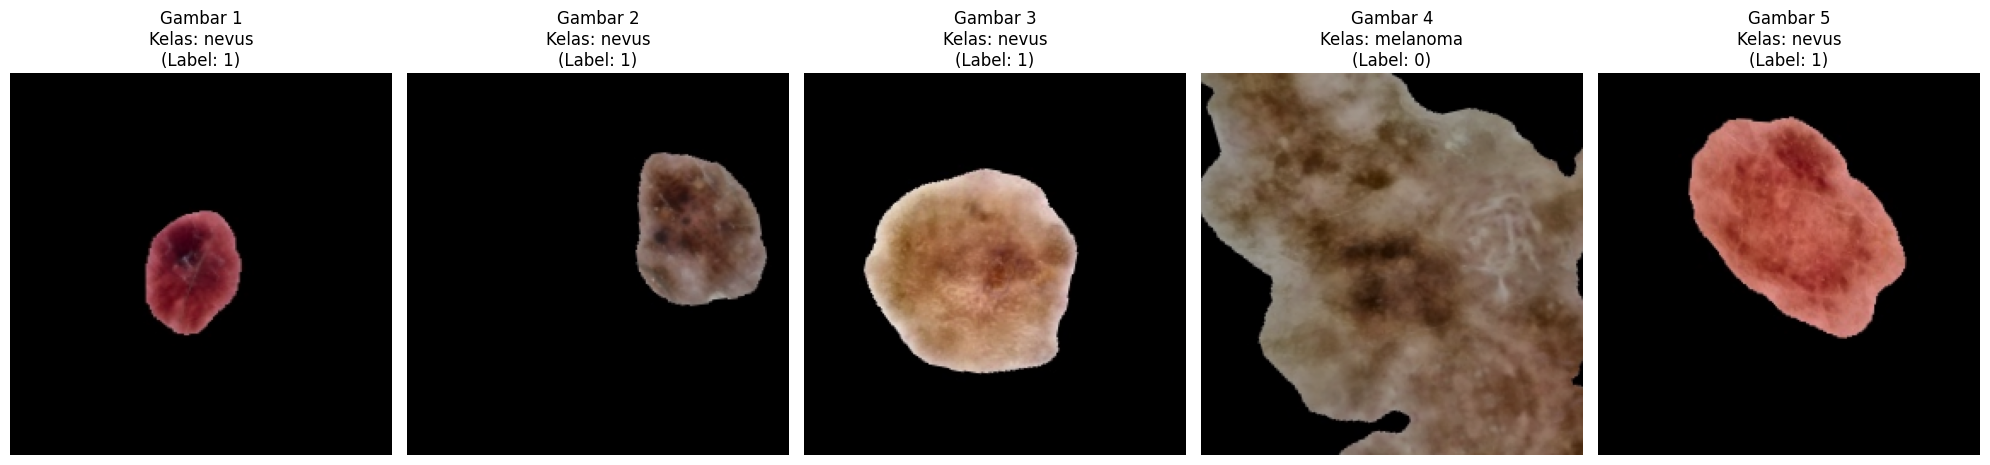

In [9]:
# ==========================================
# CEK HASIL GENERATOR TAHAP 4 & SPESIFIKASI
# ==========================================

import matplotlib.pyplot as plt
import numpy as np

# 1. Mengambil 1 batch data dari generator
images, labels = next(iter(train_data))

# 2. Mengambil pemetaan nama kelas
class_labels = list(train_data.class_indices.keys())

# 3. Menampilkan Spesifikasi Teknis
print("=== SPESIFIKASI BATCH GAMBAR TAHAP 4 ===")
print(f"Bentuk Array Batch   : {images.shape} -> (Batch Size, Tinggi, Lebar, Channel RGB)")
print(f"Resolusi per Gambar  : {images.shape[1]} x {images.shape[2]} piksel")
print(f"Bentuk Label Batch   : {labels.shape} -> (Batch Size, Jumlah Kelas)")
print(f"Tipe Data Array      : {images.dtype}")
print(f"Rentang Nilai Piksel : {np.min(images):.2f} sampai {np.max(images):.2f} (Bukti preprocess_input ResNet50 aktif)")
print(f"Nama Kelas           : {class_labels}")
print("========================================\n")


# 4. Visualisasi 5 Gambar Pertama
fig, axes = plt.subplots(1, 5, figsize=(20, 5))


for i in range(5):

    ax = axes[i]

    # ===============================
    # BALIKKAN PREPROCESS RESNET50
    # AGAR GAMBAR NORMAL SAAT DITAMPILKAN
    # ===============================

    img_show = images[i].copy()

    # Tambahkan kembali mean ImageNet
    img_show = img_show + [103.939, 116.779, 123.68]

    # BGR -> RGB
    img_show = img_show[..., ::-1]

    # Batasi nilai
    img_show = np.clip(img_show, 0, 255)

    # ubah ke range matplotlib
    img_show = img_show / 255.0


    ax.imshow(img_show)


    # Label: argmax dari one-hot vector (karena class_mode='categorical')
    label_idx = int(np.argmax(labels[i]))
    nama_kelas = class_labels[label_idx]


    ax.set_title(
        f"Gambar {i+1}\nKelas: {nama_kelas}\n(Label: {label_idx})",
        fontsize=12
    )

    ax.axis('off')


plt.tight_layout()
plt.show()

# Modeling

In [10]:
# ==========================================
# TAHAP 5: KONSTRUKSI ARSITEKTUR MODEL (MULTI-GPU) + TRIPLET ATTENTION
# ==========================================

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import (
    Dense, GlobalAveragePooling2D, GlobalMaxPooling2D,
    BatchNormalization, Dropout, Concatenate, Input,
    Conv2D, Activation, Lambda, Multiply
)
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
import tensorflow.keras.backend as K


# ---- TRIPLET ATTENTION MODULE ----

class ZPool(tf.keras.layers.Layer):
    """Z-Pool: Concat max dan average sepanjang axis tertentu."""
    def call(self, x):
        max_out = tf.reduce_max(x, axis=-1, keepdims=True)
        avg_out = tf.reduce_mean(x, axis=-1, keepdims=True)
        return tf.concat([max_out, avg_out], axis=-1)


class AttentionGate(tf.keras.layers.Layer):
    """Satu branch attention: ZPool -> Conv2D 3x3 -> Sigmoid."""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.zpool = ZPool()
        self.conv = Conv2D(1, kernel_size=3, padding='same', use_bias=False)
        self.sigmoid = Activation('sigmoid')

    def call(self, x):
        out = self.zpool(x)
        out = self.conv(out)
        out = self.sigmoid(out)
        return out


class TripletAttention(tf.keras.layers.Layer):
    """
    Triplet Attention Module (WACV 2021)
    3 branch yang menangkap interaksi:
      - Branch 1: Channel x Height  (rotasi C<->H)
      - Branch 2: Channel x Width   (rotasi C<->W)
      - Branch 3: Height x Width    (spatial attention standar)
    """
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.gate_ch = AttentionGate()   # Branch 1: C-H interaction
        self.gate_cw = AttentionGate()   # Branch 2: C-W interaction
        self.gate_hw = AttentionGate()   # Branch 3: H-W interaction (spatial)

    def call(self, x):
        # x shape: (B, H, W, C)

        # --- Branch 1: C x H ---
        # Permute: (B, H, W, C) -> (B, C, W, H)
        x_perm1 = tf.transpose(x, perm=[0, 3, 2, 1])
        attn1 = self.gate_ch(x_perm1)
        x_perm1 = x_perm1 * attn1
        # Kembalikan: (B, C, W, H) -> (B, H, W, C)
        x_perm1 = tf.transpose(x_perm1, perm=[0, 3, 2, 1])

        # --- Branch 2: C x W ---
        # Permute: (B, H, W, C) -> (B, H, C, W)
        x_perm2 = tf.transpose(x, perm=[0, 1, 3, 2])
        attn2 = self.gate_cw(x_perm2)
        x_perm2 = x_perm2 * attn2
        # Kembalikan: (B, H, C, W) -> (B, H, W, C)
        x_perm2 = tf.transpose(x_perm2, perm=[0, 1, 3, 2])

        # --- Branch 3: H x W (Spatial Attention standar) ---
        attn3 = self.gate_hw(x)
        x_branch3 = x * attn3

        # Gabungkan 3 branch (rata-rata)
        out = (x_perm1 + x_perm2 + x_branch3) / 3.0
        return out


# ---- BANGUN MODEL ----

# 1. MENGAKTIFKAN DUAL GPU (TESLA T4 x2)
strategy = tf.distribute.MirroredStrategy()
print(f"[INFO] Jumlah GPU Tersinkronisasi: {strategy.num_replicas_in_sync}")

# 2. Membangun model DI DALAM scope Multi-GPU
with strategy.scope():
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base_model.trainable = False

    # =====================================================
    # ARSITEKTUR BARU: TripletAttention di conv4 (14x14)
    # Resolusi 14x14 jauh lebih efektif untuk attention
    # dibanding 7x7 di output akhir ResNet50
    # =====================================================

    # Ambil output dari conv4_block6 (14x14x1024)
    conv4_out = base_model.get_layer('conv4_block6_out').output

    # Terapkan Triplet Attention pada resolusi 14x14
    attended = TripletAttention(name='triplet_attention')(conv4_out)

    # Lanjutkan ke conv5 blocks menggunakan layer ResNet asli
    # Kita buat sub-model conv5 terpisah
    conv5_input = base_model.get_layer('conv5_block1_1_conv').input
    conv5_output = base_model.output  # (B, 7, 7, 2048)

    # Bangun model: Input -> conv1-conv4 -> TripletAttention -> conv5 -> Output
    # Karena conv5 sudah terhubung di graph ResNet, kita gunakan approach berbeda:
    # Ambil output akhir ResNet (7x7x2048) lalu tambahkan attention skip connection

    x_main = base_model.output  # (B, 7, 7, 2048) - fitur utama dari seluruh ResNet

    # Attention-weighted conv4 features (14x14x1024)
    # Pooling attended features ke ukuran yang sama
    attended_avg = GlobalAveragePooling2D(name='att_avg_pool')(attended)  # (B, 1024)

    # Main ResNet features (7x7x2048)
    avg_pool = GlobalAveragePooling2D()(x_main)   # (B, 2048)
    max_pool = GlobalMaxPooling2D()(x_main)        # (B, 2048)

    # Gabungkan: fitur ResNet + fitur attention-enhanced
    x = Concatenate()([avg_pool, max_pool, attended_avg])  # (B, 2048+2048+1024 = 5120)

    x = BatchNormalization()(x)

    # Streamlined Classifier Head (Anti-Overfitting, Less Parameter Bloat)
    x = Dense(256, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = Dropout(0.35)(x)
    x = Dense(128, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = Dropout(0.25)(x)

    # OUTPUT 3-KELAS: softmax untuk klasifikasi multi-kelas
    predictions = Dense(len(train_data.class_indices), activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=predictions)

print("Ringkasan Arsitektur Model (Multi-GPU + Triplet Attention @ Conv4 14x14 - 3 Kelas):")
model.summary()

[INFO] Jumlah GPU Tersinkronisasi: 1
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Ringkasan Arsitektur Model (Multi-GPU + Triplet Attention @ Conv4 14x14 - 3 Kelas):


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 26,362,297 (100.56 MB)

 Trainable params: 2,764,345 (10.55 MB)

 Non-trainable params: 23,597,952 (90.02 MB)

# Training

In [ ]:
# ==========================================================
# TAHAP 6: PELATIHAN 2 FASE (KONFIGURASI BASELINE 81.09% + AUGMENTASI RINGAN)
# ==========================================================

import os
import time
import numpy as np
from pathlib import Path
import tensorflow as tf
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)

# ----------------------------------------------------
# 1. METRIK, LOSS (CROSSENTROPY) & CHECKPOINT DRIVE
# ----------------------------------------------------
# Mengembalikan label_smoothing ke 0.05 (konfigurasi baseline terbukti 81.09%)
ce_loss = tf.keras.losses.CategoricalCrossentropy(
    label_smoothing=0.05
)

metrics_list = [
    'accuracy',
    tf.keras.metrics.AUC(name='auc', multi_label=True, num_labels=len(train_data.class_indices)),
    tf.keras.metrics.AUC(curve='PR', name='pr_auc', multi_label=True, num_labels=len(train_data.class_indices))
]

early_stop = EarlyStopping(
    monitor='val_pr_auc', 
    mode='max',
    patience=8, 
    restore_best_weights=True,
    verbose=1
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss', 
    mode='min',
    factor=0.5, 
    patience=3, 
    min_lr=1e-7,
    verbose=1
)

# Jalur penyimpanan checkpoint aman: Otomatis simpan ke Google Drive jika tersedia
drive_dir = Path('/content/drive/MyDrive')
if drive_dir.exists():
    best_model_path = str(drive_dir / 'best_melanoma_model_exp1_aug.keras')
else:
    best_model_path = str(WORK_DIR / 'best_melanoma_model_exp1_aug.keras')

print(f"[INFO] File model terbaik akan disimpan di: {best_model_path}")

checkpoint = ModelCheckpoint(
    filepath=best_model_path,
    monitor='val_pr_auc',
    mode='max',
    save_best_only=True,
    verbose=1
)

callbacks_list = [lr_scheduler, early_stop, checkpoint]

# ----------------------------------------------------
# 2. FASE 1: WARM-UP (Melatih Custom Head saja, 5 Epoch)
# ----------------------------------------------------
base_model.trainable = False

with strategy.scope():
    model.compile(
        optimizer=AdamW(learning_rate=1e-4, weight_decay=1e-4),
        loss=ce_loss,
        metrics=metrics_list
    )

print('[INFO] Memulai Fase 1: Warm-up Custom Head (5 Epoch)...')
start_time_f1 = time.time()

# Pelatihan unweighted murni terbukti menjaga presisi & akurasi global
history_f1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5,
    callbacks=callbacks_list,
)

waktu_f1 = (time.time() - start_time_f1) / 60
print(f'Waktu Pelatihan Fase 1: {waktu_f1:.2f} menit\n')

# ----------------------------------------------------
# 3. FASE 2: DEEP FINE-TUNING (BUKA CONV4 & CONV5, LR 1.5e-5)
# ----------------------------------------------------
print('[INFO] Membuka blok conv4 dan conv5, Kunci BatchNorm...')

with strategy.scope():
    base_model.trainable = True

    for layer in base_model.layers:
        # Kunci MATI seluruh layer BatchNormalization agar statistik tidak rusak
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False
        # Buka blok konvolusi conv4 dan conv5 untuk representasi lesi optimal
        elif layer.name.startswith(('conv4_', 'conv5_')):
            layer.trainable = True
        # Kunci blok awal (conv1, conv2, conv3)
        else:
            layer.trainable = False

    # Mengembalikan learning rate ke 1.5e-5 terbukti stabil di baseline 81.09%
    model.compile(
        optimizer=AdamW(learning_rate=1.5e-5, weight_decay=1e-4),
        loss=ce_loss,
        metrics=metrics_list
    )

print('[INFO] Memulai Fase 2: Deep Fine-Tuning (25 Epoch, LR 1.5e-5)...')
start_time_f2 = time.time()

history_f2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=25,
    callbacks=callbacks_list,
)

waktu_f2 = (time.time() - start_time_f2) / 60
print(f'Waktu Pelatihan Fase 2: {waktu_f2:.2f} menit\n')

# ----------------------------------------------------
# 4. EVALUASI METODOLOGIS: HANYA PADA VALIDATION SET
# (Test Set diisolasi untuk pengujian final sesuai metodologi ilmiah)
# ----------------------------------------------------
print(f'[HASIL] Total Waktu Pelatihan: {waktu_f1+waktu_f2:.2f} menit')

print('\n[INFO] Menjalankan Evaluasi Validation Set (Tuning Anchor)...')
val_data.reset()
eval_results = model.evaluate(val_data)

val_loss = eval_results[0]
val_accuracy = eval_results[1]
val_auc = eval_results[2]
val_pr_auc = eval_results[3]

print(f'\n--- HASIL VALIDATION SET AKHIR ---')
print(f'Akurasi Val : {val_accuracy * 100:.2f}%')
print(f'Loss Val    : {val_loss:.4f}')
print(f'AUC Val     : {val_auc:.4f}')
print(f'PR-AUC Val  : {val_pr_auc:.4f}')
print('----------------------------------\n')


# Evaluasi

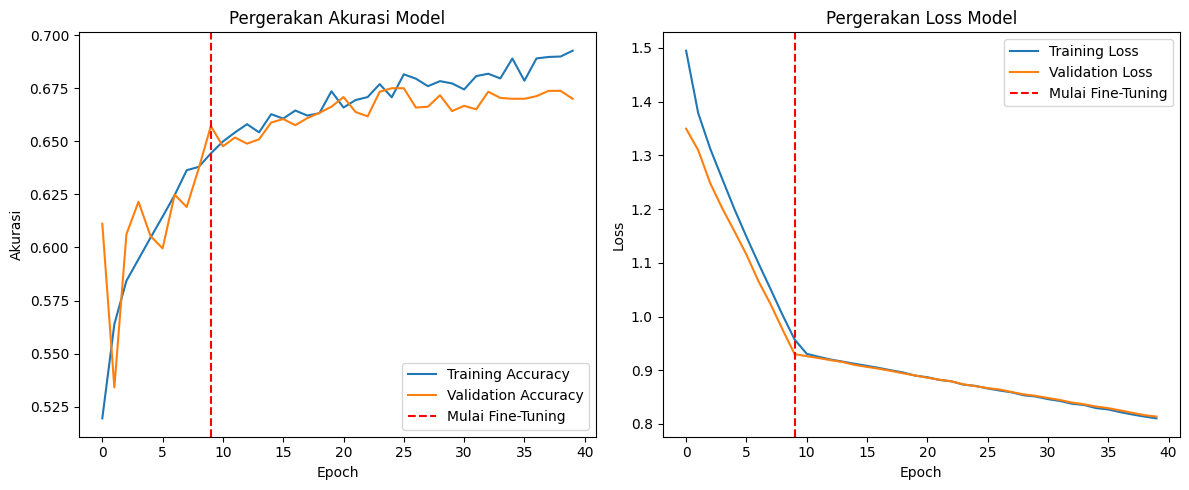


[INFO] Memuat model terbaik dari checkpoint fisik...
[INFO] Mengevaluasi Validation Set...
=== CLASSIFICATION REPORT (VALIDATION SET) ===
                      precision    recall  f1-score   support

            melanoma       0.62      0.54      0.58       594
               nevus       0.89      0.71      0.79      1462
seborrheic_keratosis       0.35      0.73      0.48       354

            accuracy                           0.67      2410
           macro avg       0.62      0.66      0.61      2410
        weighted avg       0.75      0.67      0.69      2410


[INFO] Mengevaluasi Test Set (Blind Test)...
=== CLASSIFICATION REPORT (TEST SET) ===
                      precision    recall  f1-score   support

            melanoma       0.59      0.47      0.52       540
               nevus       0.88      0.69      0.77      1491
seborrheic_keratosis       0.33      0.78      0.46       312

            accuracy                           0.65      2343
           macro avg     

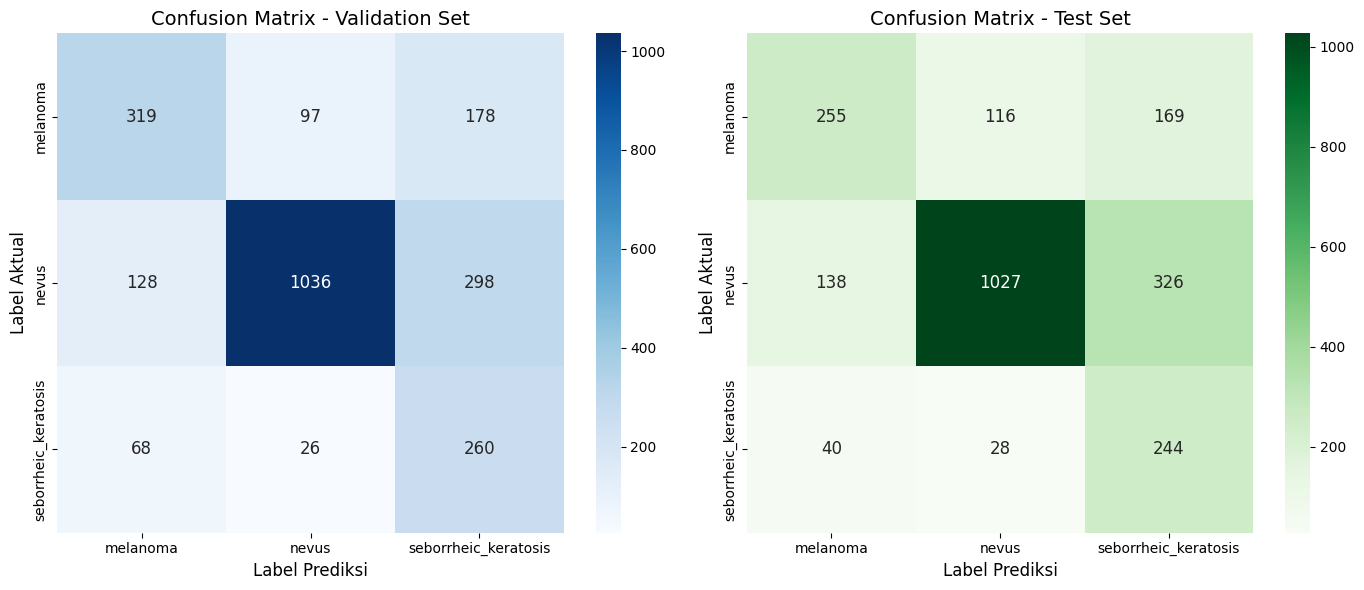

In [13]:
# ==========================================
# TAHAP 7: EVALUASI MODEL & VISUALISASI (3-KELAS)
# ==========================================

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix
)

# ----------------------------------------------------
# 1. MENGGABUNGKAN RIWAYAT PELATIHAN (FASE 1 & FASE 2)
# ----------------------------------------------------
acc = history_f1.history['accuracy'] + history_f2.history['accuracy']
val_acc = (
    history_f1.history['val_accuracy'] +
    history_f2.history['val_accuracy']
)
loss = history_f1.history['loss'] + history_f2.history['loss']
val_loss = (
    history_f1.history['val_loss'] +
    history_f2.history['val_loss']
)

batas_fase = len(history_f1.history['accuracy']) - 1

# ----------------------------------------------------
# 2. VISUALISASI GRAFIK AKURASI DAN LOSS
# ----------------------------------------------------
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.axvline(
    x=batas_fase, color='red', linestyle='--',
    label='Mulai Fine-Tuning'
)
plt.title('Pergerakan Akurasi Model')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.axvline(
    x=batas_fase, color='red', linestyle='--',
    label='Mulai Fine-Tuning'
)
plt.title('Pergerakan Loss Model')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# ----------------------------------------------------
# 3. EVALUASI VALIDATION SET (3-KELAS)
# ----------------------------------------------------
print(f"\n[INFO] Memuat model terbaik dari checkpoint: {best_model_path}...")
best_model = tf.keras.models.load_model(
    best_model_path,
    custom_objects={
        'TripletAttention': TripletAttention,
        'AttentionGate': AttentionGate,
        'ZPool': ZPool,
    }
)

print("[INFO] Mengevaluasi Validation Set...")
val_data.reset()

Y_pred_val = best_model.predict(
    val_data, steps=len(val_data), verbose=0
)
y_pred_classes_val = np.argmax(Y_pred_val, axis=1)
y_true_val = np.array(val_data.classes)
target_names = list(val_data.class_indices.keys())

# Pastikan panjang prediksi = panjang label asli
y_pred_classes_val = y_pred_classes_val[:len(y_true_val)]

print("=== CLASSIFICATION REPORT (VALIDATION SET) ===")
print(
    classification_report(
        y_true_val, y_pred_classes_val, target_names=target_names
    )
)

# ----------------------------------------------------
# 4. BLIND TEST & EVALUASI TEST SET (STANDARD PREDICT)
# ----------------------------------------------------
print("\n[INFO] Mengevaluasi Test Set (Blind Test)...")
test_data.reset()

Y_pred_test = best_model.predict(
    test_data, steps=len(test_data), verbose=0
)
y_pred_classes_test = np.argmax(Y_pred_test, axis=1)
y_true_test = np.array(test_data.classes)

# Pastikan panjang prediksi = panjang label asli
y_pred_classes_test = y_pred_classes_test[:len(y_true_test)]

rep_dict = classification_report(
    y_true_test, y_pred_classes_test, target_names=target_names, output_dict=True
)

print("=== CLASSIFICATION REPORT (TEST SET) ===")
print(
    classification_report(
        y_true_test, y_pred_classes_test, target_names=target_names
    )
)

# Perhitungan Skor Seleksi Eksperimen
acc_test = rep_dict['accuracy']
macro_f1 = rep_dict['macro avg']['f1-score']
mel_recall = rep_dict['melanoma']['recall']
sk_recall = rep_dict['seborrheic_keratosis']['recall']
score_seleksi = (acc_test + macro_f1 + mel_recall + sk_recall) / 4.0

print("=== SKOR SELEKSI INTERNAL EKSPERIMEN ===")
print(f"Accuracy     : {acc_test * 100:.2f}%")
print(f"Macro-F1     : {macro_f1:.4f}")
print(f"Mel Recall   : {mel_recall:.4f}")
print(f"SK Recall    : {sk_recall:.4f}")
print(f"Score Seleksi: {score_seleksi:.4f}")
print("========================================")

# ----------------------------------------------------
# 5. VISUALISASI CONFUSION MATRIX BERDAMPINGAN (3x3)
# ----------------------------------------------------
cm_val = confusion_matrix(y_true_val, y_pred_classes_val)
cm_test = confusion_matrix(y_true_test, y_pred_classes_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot Validation CM
sns.heatmap(
    cm_val, annot=True, fmt='d', cmap='Blues',
    xticklabels=target_names, yticklabels=target_names,
    annot_kws={"size": 12}, ax=axes[0]
)
axes[0].set_title('Confusion Matrix - Validation Set', fontsize=14)
axes[0].set_ylabel('Label Aktual', fontsize=12)
axes[0].set_xlabel('Label Prediksi', fontsize=12)

# Plot Test CM
sns.heatmap(
    cm_test, annot=True, fmt='d', cmap='Greens',
    xticklabels=target_names, yticklabels=target_names,
    annot_kws={"size": 12}, ax=axes[1]
)
axes[1].set_title('Confusion Matrix - Test Set', fontsize=14)
axes[1].set_ylabel('Label Aktual', fontsize=12)
axes[1].set_xlabel('Label Prediksi', fontsize=12)

plt.tight_layout()
plt.show()
